# Inicialização de bibliotecas e configurações

In [ ]:
# Imports necessários

# 1. BIBLIOTECAS BÁSICAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from datetime import datetime

# 2. PRÉ-PROCESSAMENTO E DIVISÃO DE DADOS
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline

# 3. MODELOS (ALGORITMOS)
from sklearn.tree import DecisionTreeClassifier      # CART
from sklearn.neighbors import KNeighborsClassifier   # KNN
from sklearn.naive_bayes import GaussianNB           # Naive Bayes
from sklearn.svm import SVC                          # SVM

# 4. MÉTRICAS DE AVALIAÇÃO
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# 5. EXPORTAÇÃO DO MODELO
import joblib
import json

# 6. CONFIGURAÇÕES INICIAIS
import warnings
warnings.filterwarnings("ignore")

# Configurações de visualização
plt.style.use('default')
sns.set_palette("Set2")

# Semente global para reprodutibilidade
np.random.seed(7)

# Carregamento do Dataset

In [ ]:
# URL do arquivo de importação do dataset
url = "https://raw.githubusercontent.com/FernandoSAO/Fernando-4052025000277-Qualidade_de_Software_Seguranca_Sistemas_Inteligentes/refs/heads/main/loan_data.csv"

# Lê o arquivo
dataset = pd.read_csv(url, delimiter=',')

# Remove espaço em branco
dataset.columns = dataset.columns.str.strip()

# Mostra as primeiras linhas do dataset
dataset.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


# Remoção de clientes com previous_loan_defaults_on_file = Yes

Durante a análise exploratória dos dados, foi observado que todos os clientes com histórico de inadimplência anterior (previous_loan_defaults_on_file = Yes) tiveram seus empréstimos negados, independentemente dos demais fatores avaliados.

Para evitar que essa relação determinística influencie negativamente o aprendizado do modelo, mascarando a importância real de outras variáveis como renda, score de crédito e experiência profissional, optou-se por remover esses registros do conjunto de treinamento.

A lógica de negação automática para clientes com inadimplência anterior será implementada separadamente como uma regra de negócio explícita, garantindo maior transparência e controle sobre essa decisão.

In [ ]:
# remove as linhas com default=Yes
dataset = dataset[dataset['previous_loan_defaults_on_file'] == 'No']

# remove a coluna (agora é constante)
dataset = dataset.drop(columns=['previous_loan_defaults_on_file'])

# Converter coluna person_gender em valores 0/1
*   female = 0
*   male = 1

# Converter colunas em multiplas colunas 0/1

person_education

*   Associate -> person_education_Associate
*   Bachelor -> person_education_Bachelor
*   Doctorate -> person_education_Doctorate
*   High_School -> person_education_High_School
*   Master -> person_education_Master

person_home_ownership

*   MORTGAGE -> person_home_ownership_MORTGAGE
*   OTHER -> person_home_ownership_OTHER
*   OWN -> person_home_ownership_OWN
*   RENT -> person_home_ownership_RENT

loan_intent

*   DEBTCONSOLIDATION -> loan_intent_DEBTCONSOLIDATION
*   EDUCATION -> loan_intent_EDUCATION
*   HOMEIMPROVEMENT -> loan_intent_HOMEIMPROVEMENT
*   MEDICAL -> loan_intent_MEDICAL
*   PERSONAL -> loan_intent_PERSONAL
*   VENTURE -> loan_intent_VENTURE

In [ ]:
# modificando coluna person_gender
dataset['person_gender'] = dataset['person_gender'].map({'female': 0, 'male': 1})

# escolhas das colunas categóricas
categorical_columns  = ['person_education', 'person_home_ownership', 'loan_intent']

# imprime valores únicos para colunas categóricas
for col in categorical_columns:
    unique_vals = dataset[col].unique()
    print(f"\n{col}: {sorted(unique_vals)}")
    print(f"   {len(unique_vals)} categories")

# One-hot encoding
dataset = pd.get_dummies(dataset, columns=categorical_columns, drop_first=False, dtype=int)

# Mostra as primeiras linhas do dataset com as modificações
dataset.head()


person_education: ['Associate', 'Bachelor', 'Doctorate', 'High School', 'Master']
   5 categories

person_home_ownership: ['MORTGAGE', 'OTHER', 'OWN', 'RENT']
   4 categories

loan_intent: ['DEBTCONSOLIDATION', 'EDUCATION', 'HOMEIMPROVEMENT', 'MEDICAL', 'PERSONAL', 'VENTURE']
   6 categories


,person_age,person_gender,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status,...,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22.0,0,71948.0,0,35000.0,16.02,0.49,3.0,561,1,...,0,0,0,1,0,0,0,0,1,0
2,25.0,0,12438.0,3,5500.0,12.87,0.44,3.0,635,1,...,1,0,0,0,0,0,0,1,0,0
3,23.0,0,79753.0,0,35000.0,15.23,0.44,2.0,675,1,...,0,0,0,1,0,0,0,1,0,0
4,24.0,1,66135.0,1,35000.0,14.27,0.53,4.0,586,1,...,0,0,0,1,0,0,0,1,0,0
5,21.0,0,12951.0,0,2500.0,7.14,0.19,2.0,532,1,...,0,0,1,0,0,0,0,0,0,1


# Nome das colunas com as alterações

In [ ]:
print("Nomes das colunas após transformação:")
for i, col in enumerate(dataset.columns):
    print(f"{i}: {col}")

Nomes das colunas após transformação:
0: person_age
1: person_gender
2: person_income
3: person_emp_exp
4: loan_amnt
5: loan_int_rate
6: loan_percent_income
7: cb_person_cred_hist_length
8: credit_score
9: loan_status
10: person_education_Associate
11: person_education_Bachelor
12: person_education_Doctorate
13: person_education_High School
14: person_education_Master
15: person_home_ownership_MORTGAGE
16: person_home_ownership_OTHER
17: person_home_ownership_OWN
18: person_home_ownership_RENT
19: loan_intent_DEBTCONSOLIDATION
20: loan_intent_EDUCATION
21: loan_intent_HOMEIMPROVEMENT
22: loan_intent_MEDICAL
23: loan_intent_PERSONAL
24: loan_intent_VENTURE


# Separação em conjunto de treino e conjunto de teste com holdout

In [ ]:
test_size = 0.20 # tamanho do conjunto de teste
seed = 5 # semente aleatória

# Separação em x e y
target_column = 'loan_status'
feature_columns = [col for col in dataset.columns if col != target_column]
X = dataset[feature_columns].values
y = dataset[target_column].values

X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=test_size, shuffle=True, random_state=seed, stratify=y) # holdout com estratificação

# Parâmetros e partições da validação cruzada
scoring = 'accuracy'
num_particoes = 10
kfold = StratifiedKFold(n_splits=num_particoes, shuffle=True, random_state=seed) # validação cruzada com estratificação

# Criação e avaliação de modelos: linha base

KNN: 0.760514 (0.008331)
CART: 0.795688 (0.008606)
NB: 0.591601 (0.023041)
SVM: 0.712021 (0.013940)


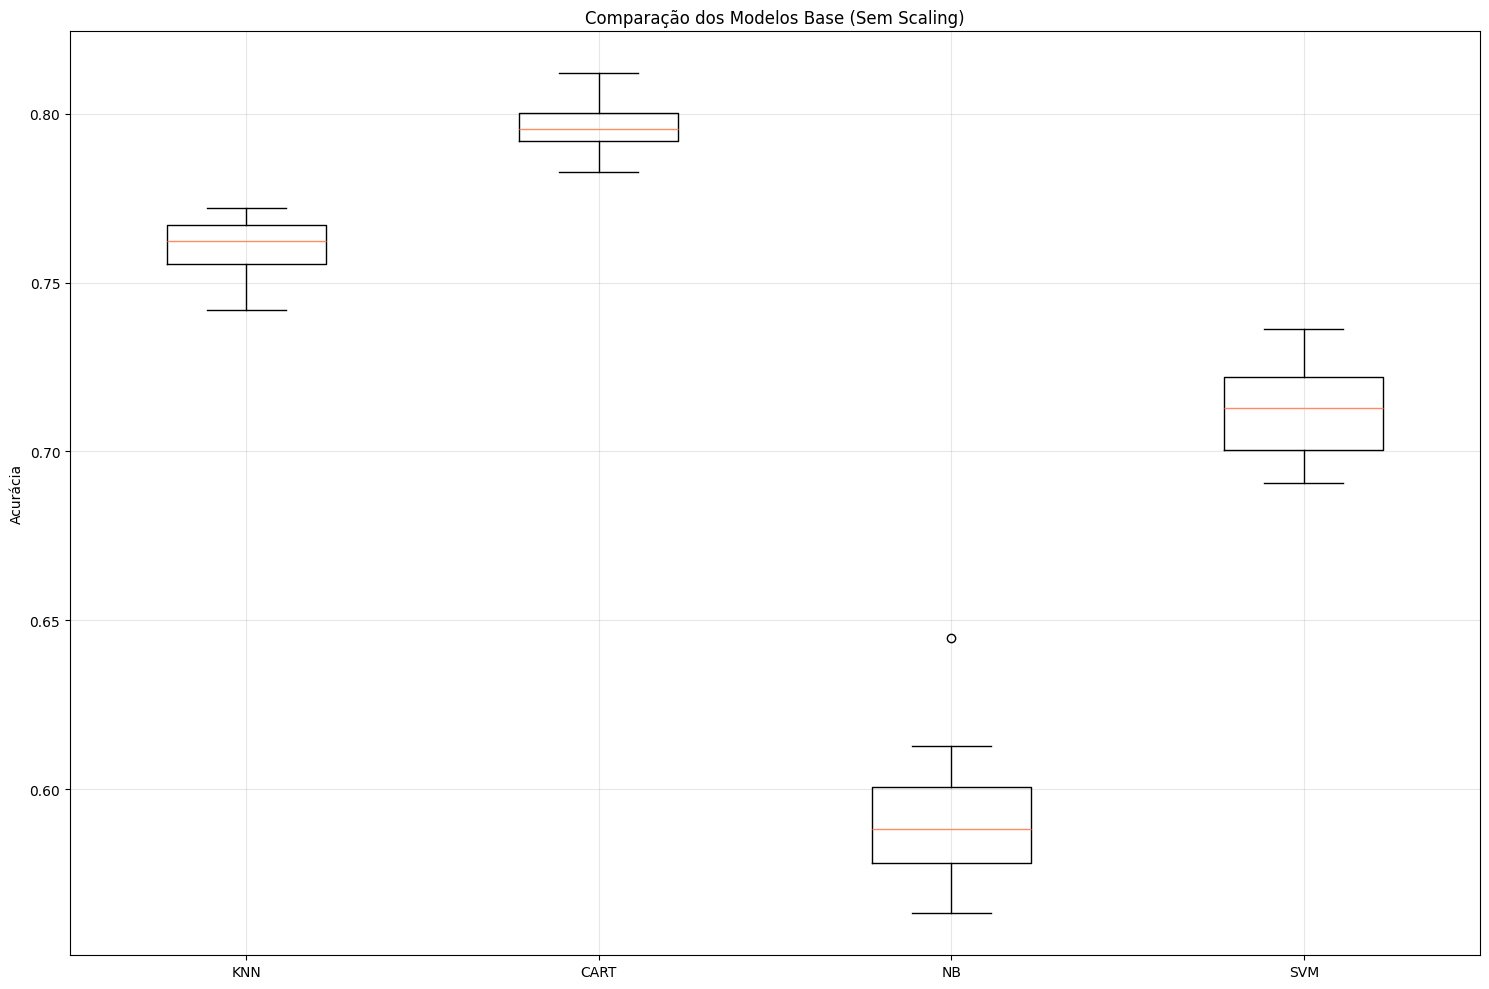

In [ ]:
np.random.seed(7)

models = []
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))

results_base = []
names_base = []

for name, model in models:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    results_base.append(cv_results)
    names_base.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

# Boxplot dos modelos base
plt.figure(figsize=(15,10))
plt.title('Comparação dos Modelos Base (Sem Scaling)')
plt.boxplot(results_base)
plt.xticks(range(1, len(names_base) + 1), names_base)
plt.ylabel('Acurácia')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Criação e avaliação de modelos: dados padronizados e normalizados

Calculando: KNN-padr... ✅ 0.775 (+/- 0.008)
Calculando: CART-padr... ✅ 0.795 (+/- 0.009)
Calculando: NB-padr... ✅ 0.709 (+/- 0.013)
Calculando: SVM-padr... ✅ 0.825 (+/- 0.011)
Calculando: KNN-norm... ✅ 0.774 (+/- 0.008)
Calculando: CART-norm... ✅ 0.796 (+/- 0.010)
Calculando: NB-norm... ✅ 0.709 (+/- 0.013)
Calculando: SVM-norm... ✅ 0.817 (+/- 0.008)


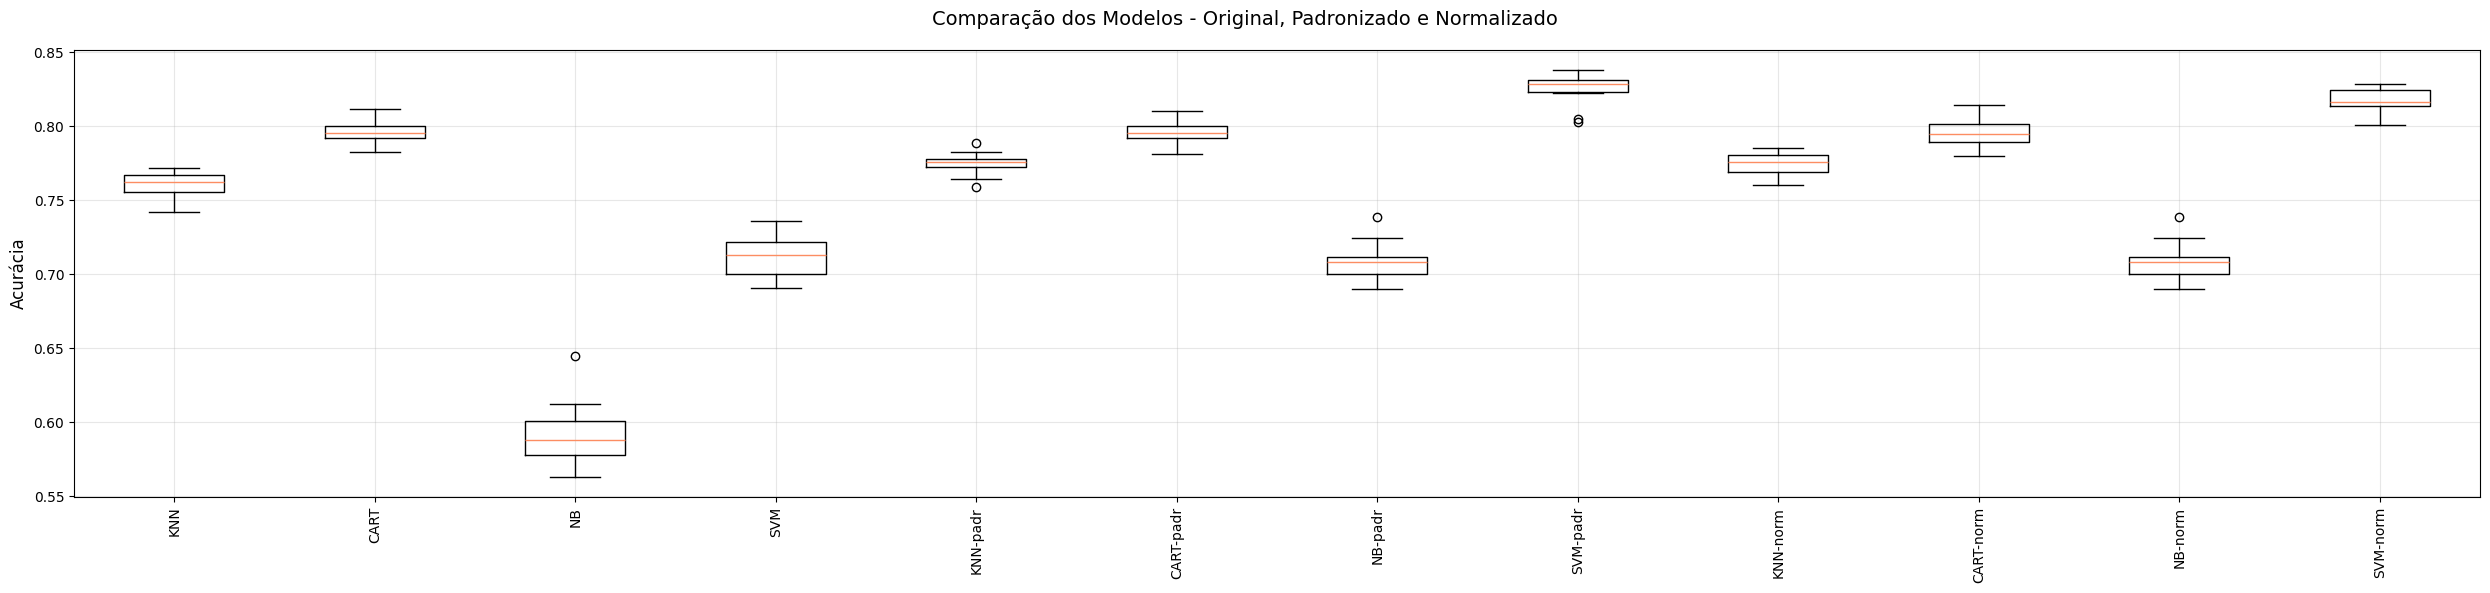


🏆 MELHOR MODELO GERAL: SVM-padr
   Score médio: 0.8248


In [ ]:
np.random.seed(7)

# Iniciar com resultados anteriores
results_completos = results_base.copy()
names_completos = names_base.copy()

# Criando os elementos do pipeline
knn = ('KNN', KNeighborsClassifier())
cart = ('CART', DecisionTreeClassifier())
naive_bayes = ('NB', GaussianNB())
svm = ('SVM', SVC())

standard_scaler = ('StandardScaler', StandardScaler())
min_max_scaler = ('MinMaxScaler', MinMaxScaler())

# Criar pipelines APENAS para os modelos com scaling
pipelines_scaling = []

# Dataset Padronizado
pipelines_scaling.append(('KNN-padr', Pipeline([standard_scaler, knn])))
pipelines_scaling.append(('CART-padr', Pipeline([standard_scaler, cart])))
pipelines_scaling.append(('NB-padr', Pipeline([standard_scaler, naive_bayes])))
pipelines_scaling.append(('SVM-padr', Pipeline([standard_scaler, svm])))

# Dataset Normalizado
pipelines_scaling.append(('KNN-norm', Pipeline([min_max_scaler, knn])))
pipelines_scaling.append(('CART-norm', Pipeline([min_max_scaler, cart])))
pipelines_scaling.append(('NB-norm', Pipeline([min_max_scaler, naive_bayes])))
pipelines_scaling.append(('SVM-norm', Pipeline([min_max_scaler, svm])))

# Executar APENAS os pipelines com scaling
for name, model in pipelines_scaling:
    print(f"Calculando: {name}...", end=" ", flush=True)
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    results_completos.append(cv_results)
    names_completos.append(name)
    print(f"✅ {cv_results.mean():.3f} (+/- {cv_results.std():.3f})")

# Boxplot COMPLETO
plt.figure(figsize=(25,6))
plt.suptitle('Comparação dos Modelos - Original, Padronizado e Normalizado', fontsize=14)
ax = plt.gca()
plt.boxplot(results_completos)
plt.xticks(range(1, len(names_completos) + 1), names_completos, rotation=90, fontsize=10)
plt.ylabel('Acurácia', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Identificar o melhor modelo geral
melhor_idx = np.argmax([np.mean(r) for r in results_completos])
print(f"\n🏆 MELHOR MODELO GERAL: {names_completos[melhor_idx]}")
print(f"   Score médio: {results_completos[melhor_idx].mean():.4f}")

# Otimização dos hiperparâmetros (com escolha automática do melhor previamente calculado para cada modelo)

Devido ao tempo de execução do SVM (cerca de 4 min por teste), preferi otimizar apenas os outros 3 modelos

In [ ]:
# Modelos a ser optimizados (excluindo SVM)
modelos_para_tunar = ['KNN', 'CART', 'NB']

# Dicionário para armazenar a melhor versão de cada modelo
melhor_versao = {}
melhor_score_base = {}

for modelo in modelos_para_tunar:
    melhor_score = -1
    melhor_versao_nome = None

    print(f"\n--- {modelo} ---")

    # Original: nome é f"{modelo}"
    nome_orig = f"{modelo}"
    if nome_orig in names_completos:
        idx = names_completos.index(nome_orig)
        score_medio = np.mean(results_completos[idx])
        print(f"{nome_orig:12s} (orig): {score_medio:.4f}")
        if score_medio > melhor_score:
            melhor_score = score_medio
            melhor_versao_nome = 'orig'

    # Padronizado: nome é f"{modelo}-padr"
    nome_padr = f"{modelo}-padr"
    if nome_padr in names_completos:
        idx = names_completos.index(nome_padr)
        score_medio = np.mean(results_completos[idx])
        print(f"{nome_padr:12s} (padr): {score_medio:.4f}")
        if score_medio > melhor_score:
            melhor_score = score_medio
            melhor_versao_nome = 'padr'

    # Normalizado: nome é f"{modelo}-norm"
    nome_norm = f"{modelo}-norm"
    if nome_norm in names_completos:
        idx = names_completos.index(nome_norm)
        score_medio = np.mean(results_completos[idx])
        print(f"{nome_norm:12s} (norm): {score_medio:.4f}")
        if score_medio > melhor_score:
            melhor_score = score_medio
            melhor_versao_nome = 'norm'

    melhor_versao[modelo] = melhor_versao_nome
    melhor_score_base[modelo] = melhor_score

    print(f"\n🏆 Melhor {modelo}: {melhor_versao_nome} (score: {melhor_score:.4f})")
    print("-" * 50)

for modelo in modelos_para_tunar:
    print(f"{modelo:8s} -> {melhor_versao[modelo]:5s} (score base: {melhor_score_base[modelo]:.4f})")

tuning_results = {}


--- KNN ---
KNN          (orig): 0.7605
KNN-padr     (padr): 0.7746
KNN-norm     (norm): 0.7743

🏆 Melhor KNN: padr (score: 0.7746)
--------------------------------------------------

--- CART ---
CART         (orig): 0.7957
CART-padr    (padr): 0.7955
CART-norm    (norm): 0.7962

🏆 Melhor CART: norm (score: 0.7962)
--------------------------------------------------

--- NB ---
NB           (orig): 0.5916
NB-padr      (padr): 0.7093
NB-norm      (norm): 0.7093

🏆 Melhor NB: padr (score: 0.7093)
--------------------------------------------------
KNN      -> padr  (score base: 0.7746)
CART     -> norm  (score base: 0.7962)
NB       -> padr  (score base: 0.7093)


# Melhora do KNN

In [ ]:
modelo = 'KNN'
versao = melhor_versao[modelo]

print(f"\n{'='*50}")
print(f"Tuning do {modelo} - Versão: {versao}")
print(f"{'='*50}")

# Criar pipeline com a melhor versão
if versao == 'orig':
    knn_pipeline = Pipeline([('knn', KNeighborsClassifier())])
elif versao == 'padr':
    knn_pipeline = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])
else:  # norm
    knn_pipeline = Pipeline([('scaler', MinMaxScaler()), ('knn', KNeighborsClassifier())])

# Grid de parâmetros para KNN
param_knn = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'knn__metric': ['euclidean', 'manhattan'],
    'knn__weights': ['uniform', 'distance']
}

total_combinacoes = len(param_knn['knn__n_neighbors']) * len(param_knn['knn__metric']) * len(param_knn['knn__weights'])
print(f"📊 Combinações: {total_combinacoes}")
print(f"   Total treinamentos: {total_combinacoes * 5}")

start = time.time()
grid_knn = GridSearchCV(knn_pipeline, param_knn, cv=5, scoring='accuracy', n_jobs=1, verbose=1)
grid_knn.fit(X_train, y_train)
tempo = time.time() - start

print(f"\n✅ Tuning concluído em {tempo/60:.2f} min")
print(f"   Melhor score CV: {grid_knn.best_score_:.4f}")
print(f"   Melhores parâmetros: {grid_knn.best_params_}")
print(f"   Score no teste: {grid_knn.score(X_test, y_test):.4f}")

tuning_results[modelo] = {
    'grid': grid_knn,
    'best_score': grid_knn.best_score_,
    'test_score': grid_knn.score(X_test, y_test),
    'best_params': grid_knn.best_params_,
    'versao': versao
}


Tuning do KNN - Versão: padr
📊 Combinações: 28
   Total treinamentos: 140
Fitting 5 folds for each of 28 candidates, totalling 140 fits

✅ Tuning concluído em 1.85 min
   Melhor score CV: 0.7864
   Melhores parâmetros: {'knn__metric': 'manhattan', 'knn__n_neighbors': 15, 'knn__weights': 'distance'}
   Score no teste: 0.7959


# Melhora do CART

In [ ]:
modelo = 'CART'
versao = melhor_versao[modelo]

print(f"\n{'='*50}")
print(f"Tuning do {modelo} - Versão: {versao}")
print(f"{'='*50}")

# Criar pipeline com a melhor versão
if versao == 'orig':
    cart_pipeline = Pipeline([('cart', DecisionTreeClassifier(random_state=7))])
elif versao == 'padr':
    cart_pipeline = Pipeline([('scaler', StandardScaler()), ('cart', DecisionTreeClassifier(random_state=7))])
else:  # norm
    cart_pipeline = Pipeline([('scaler', MinMaxScaler()), ('cart', DecisionTreeClassifier(random_state=7))])

# Grid de parâmetros para CART
param_cart = {
    'cart__max_depth': [3, 5, 7, 10, None],
    'cart__min_samples_split': [2, 5, 10],
    'cart__criterion': ['gini', 'entropy']
}

total_combinacoes = len(param_cart['cart__max_depth']) * len(param_cart['cart__min_samples_split']) * len(param_cart['cart__criterion'])
print(f"📊 Combinações: {total_combinacoes}")
print(f"   Total treinamentos: {total_combinacoes * 5}")

start = time.time()
grid_cart = GridSearchCV(cart_pipeline, param_cart, cv=5, scoring='accuracy', n_jobs=1, verbose=1)
grid_cart.fit(X_train, y_train)
tempo = time.time() - start

print(f"\n✅ Tuning concluído em {tempo/60:.2f} min")
print(f"   Melhor score CV: {grid_cart.best_score_:.4f}")
print(f"   Melhores parâmetros: {grid_cart.best_params_}")
print(f"   Score no teste: {grid_cart.score(X_test, y_test):.4f}")

tuning_results[modelo] = {
    'grid': grid_cart,
    'best_score': grid_cart.best_score_,
    'test_score': grid_cart.score(X_test, y_test),
    'best_params': grid_cart.best_params_,
    'versao': versao
}


Tuning do CART - Versão: norm
📊 Combinações: 30
   Total treinamentos: 150
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Tuning concluído em 0.19 min
   Melhor score CV: 0.8370
   Melhores parâmetros: {'cart__criterion': 'entropy', 'cart__max_depth': 10, 'cart__min_samples_split': 5}
   Score no teste: 0.8377


# Melhora NAIVE BAYES

In [ ]:
modelo = 'NB'
versao = melhor_versao[modelo]

print(f"\n{'='*50}")
print(f"Tuning do {modelo} - Versão: {versao}")
print(f"{'='*50}")

# Criar pipeline com a melhor versão
if versao == 'orig':
    nb_pipeline = Pipeline([('nb', GaussianNB())])
elif versao == 'padr':
    nb_pipeline = Pipeline([('scaler', StandardScaler()), ('nb', GaussianNB())])
else:  # norm
    nb_pipeline = Pipeline([('scaler', MinMaxScaler()), ('nb', GaussianNB())])

# Grid de parâmetros para NB
param_nb = {
    'nb__var_smoothing': [1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

print(f"📊 Combinações: {len(param_nb['nb__var_smoothing'])}")
print(f"   Total treinamentos: {len(param_nb['nb__var_smoothing']) * 5}")

start = time.time()
grid_nb = GridSearchCV(nb_pipeline, param_nb, cv=5, scoring='accuracy', n_jobs=1, verbose=1)
grid_nb.fit(X_train, y_train)
tempo = time.time() - start

print(f"\n✅ Tuning concluído em {tempo/60:.2f} min")
print(f"   Melhor score CV: {grid_nb.best_score_:.4f}")
print(f"   Melhor var_smoothing: {grid_nb.best_params_['nb__var_smoothing']}")
print(f"   Score no teste: {grid_nb.score(X_test, y_test):.4f}")

tuning_results[modelo] = {
    'grid': grid_nb,
    'best_score': grid_nb.best_score_,
    'test_score': grid_nb.score(X_test, y_test),
    'best_params': grid_nb.best_params_,
    'versao': versao
}


Tuning do NB - Versão: padr
📊 Combinações: 6
   Total treinamentos: 30
Fitting 5 folds for each of 6 candidates, totalling 30 fits

✅ Tuning concluído em 0.01 min
   Melhor score CV: 0.7089
   Melhor var_smoothing: 1e-10
   Score no teste: 0.7110


# Comparativo dos melhores modelos e suas hiperparametrização


📊 RESULTADOS COMPARATIVOS FINAIS
-----------------------------------------------------------------------------------------------
Modelo     Versão   Score Base   Score Tunado Melhoria     Score Teste 
-----------------------------------------------------------------------------------------------
KNN        -padr    0.7746       0.7864       +1.18%      0.7959      
CART       -norm    0.7962       0.8370       +4.08%      0.8377      
NB         -padr    0.7093       0.7089       -0.04%      0.7110      
SVM        -padr    0.8248       0.8248       +0.00%      0.8248      
-----------------------------------------------------------------------------------------------

🏆 RANKING FINAL DOS MODELOS

Posição  Modelo     Versão   Score CV    
---------------------------------------------
🥇        CART       -norm    0.8370      
🥈        SVM        -padr    0.8248      
🥉        KNN        -padr    0.7864      
4º       NB         -padr    0.7089      
------------------------------------

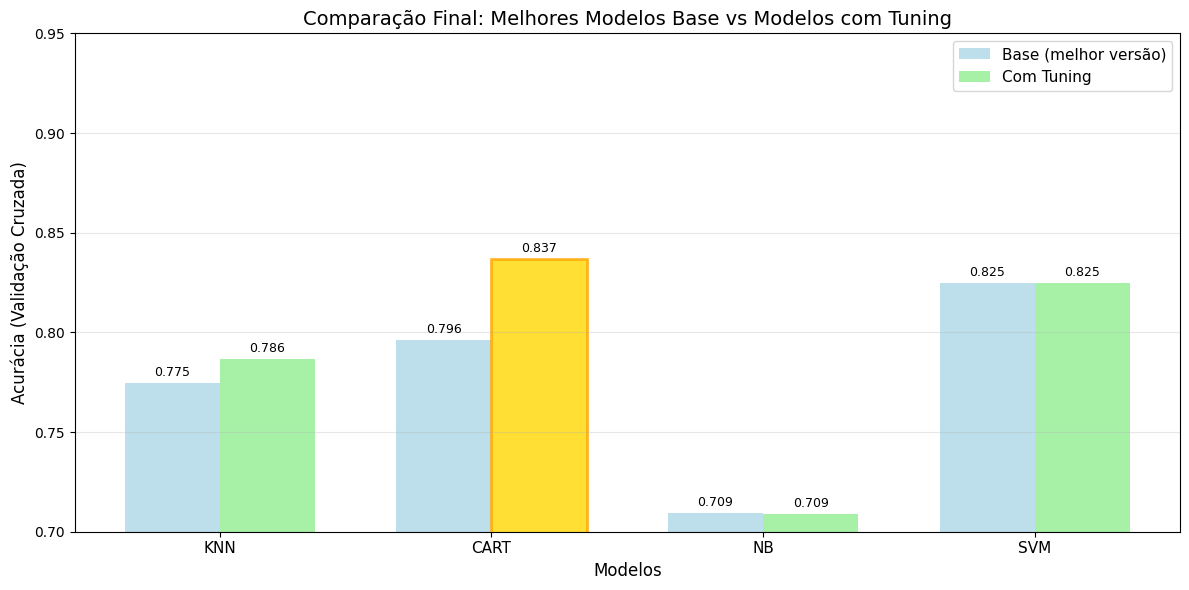


📋 RESUMO FINAL DO TRABALHO

✅ MODELOS AVALIADOS:
   - KNN: melhor versão = -padr | tunado: 0.7864
   - CART: melhor versão = -norm | tunado: 0.8370
   - NB: melhor versão = -padr | tunado: 0.7089
   - SVM: melhor versão = -padr (sem tuning)

🏆 MELHOR MODELO: CART
   - Versão: -norm
   - Score CV: 0.8370

📈 GANHOS COM TUNING:

   KNN: +1.18% de melhoria
   CART: +4.08% de melhoria
   NB: -0.04% de melhoria

🎯 CONCLUSÃO:
   O modelo CART (-norm)
   apresentou a melhor performance com acurácia de 0.8370.



In [ ]:
# Coletar os melhores resultados já calculados

resultados_final = []

# KNN: pega o melhor entre orig, padr e norm

melhor_knn_score = -1
melhor_knn_nome = None
melhor_knn_versao = None

for versao in ['', '-padr', '-norm']:
    nome = f"KNN{versao}"
    if nome in names_completos:
        idx = names_completos.index(nome)
        score = np.mean(results_completos[idx])
        if score > melhor_knn_score:
            melhor_knn_score = score
            melhor_knn_nome = nome
            melhor_knn_versao = versao if versao else 'orig'

# CART: pega o melhor entre orig, padr e norm

melhor_cart_score = -1
melhor_cart_nome = None
melhor_cart_versao = None

for versao in ['', '-padr', '-norm']:
    nome = f"CART{versao}"
    if nome in names_completos:
        idx = names_completos.index(nome)
        score = np.mean(results_completos[idx])
        if score > melhor_cart_score:
            melhor_cart_score = score
            melhor_cart_nome = nome
            melhor_cart_versao = versao if versao else 'orig'

# NB: pega o melhor entre orig, padr e norm

melhor_nb_score = -1
melhor_nb_nome = None
melhor_nb_versao = None

for versao in ['', '-padr', '-norm']:
    nome = f"NB{versao}"
    if nome in names_completos:
        idx = names_completos.index(nome)
        score = np.mean(results_completos[idx])
        if score > melhor_nb_score:
            melhor_nb_score = score
            melhor_nb_nome = nome
            melhor_nb_versao = versao if versao else 'orig'

# SVM: pega o melhor entre orig, padr e norm

melhor_svm_score = -1
melhor_svm_nome = None
melhor_svm_versao = None

for versao in ['', '-padr', '-norm']:
    nome = f"SVM{versao}"
    if nome in names_completos:
        idx = names_completos.index(nome)
        score = np.mean(results_completos[idx])
        if score > melhor_svm_score:
            melhor_svm_score = score
            melhor_svm_nome = nome
            melhor_svm_versao = versao if versao else 'orig'

# Adiciona os resultados dos modelos com ajustes de hiperparâmetros (KNN, CART, NB)

knn_tunado_score = tuning_results['KNN']['best_score']
knn_tunado_teste = tuning_results['KNN']['test_score']
cart_tunado_score = tuning_results['CART']['best_score']
cart_tunado_teste = tuning_results['CART']['test_score']
nb_tunado_score = tuning_results['NB']['best_score']
nb_tunado_teste = tuning_results['NB']['test_score']

# Tabela de resultados

resultados_final = [
    {
        'modelo': 'KNN',
        'versao': melhor_knn_versao,
        'score_base': melhor_knn_score,
        'score_tunado': knn_tunado_score,
        'score_teste': knn_tunado_teste,
        'melhoria': (knn_tunado_score - melhor_knn_score) * 100
    },
    {
        'modelo': 'CART',
        'versao': melhor_cart_versao,
        'score_base': melhor_cart_score,
        'score_tunado': cart_tunado_score,
        'score_teste': cart_tunado_teste,
        'melhoria': (cart_tunado_score - melhor_cart_score) * 100
    },
    {
        'modelo': 'NB',
        'versao': melhor_nb_versao,
        'score_base': melhor_nb_score,
        'score_tunado': nb_tunado_score,
        'score_teste': nb_tunado_teste,
        'melhoria': (nb_tunado_score - melhor_nb_score) * 100
    },
    {
        'modelo': 'SVM',
        'versao': melhor_svm_versao,
        'score_base': melhor_svm_score,
        'score_tunado': melhor_svm_score,  # SVM não teve hiperparametrização
        'score_teste': melhor_svm_score,   # mesmo valor do CV
        'melhoria': 0.0
    }
]

# Exibir tabela comparatica

print("\n" + "="*60)
print("📊 RESULTADOS COMPARATIVOS FINAIS")
print("="*60)
print("-" * 95)
print(f"{'Modelo':<10} {'Versão':<8} {'Score Base':<12} {'Score Tunado':<12} {'Melhoria':<12} {'Score Teste':<12}")
print("-" * 95)

for res in resultados_final:
    print(f"{res['modelo']:<10} {res['versao']:<8} {res['score_base']:<12.4f} {res['score_tunado']:<12.4f} {res['melhoria']:+.2f}%      {res['score_teste']:<12.4f}")

print("-" * 95)

# Ranking final

ranking = sorted(resultados_final, key=lambda x: x['score_tunado'], reverse=True)

print("\n" + "="*60)
print("🏆 RANKING FINAL DOS MODELOS")
print("="*60)
print(f"\n{'Posição':<8} {'Modelo':<10} {'Versão':<8} {'Score CV':<12}")
print("-" * 45)

for i, res in enumerate(ranking, 1):
    medalha = "🥇" if i == 1 else "🥈" if i == 2 else "🥉" if i == 3 else f"{i}º"
    print(f"{medalha:<8} {res['modelo']:<10} {res['versao']:<8} {res['score_tunado']:<12.4f}")

print("-" * 45)

# Visualização comparativa

plt.figure(figsize=(12, 6))

modelos_nomes = [res['modelo'] for res in resultados_final]
scores_base = [res['score_base'] for res in resultados_final]
scores_tunado = [res['score_tunado'] for res in resultados_final]

x = np.arange(len(modelos_nomes))
width = 0.35

bars1 = plt.bar(x - width/2, scores_base, width, label='Base (melhor versão)', color='lightblue', alpha=0.8)
bars2 = plt.bar(x + width/2, scores_tunado, width, label='Com Tuning', color='lightgreen', alpha=0.8)

# Destacar o melhor modelo

idx_melhor = modelos_nomes.index(ranking[0]['modelo'])
bars2[idx_melhor].set_color('gold')
bars2[idx_melhor].set_edgecolor('orange')
bars2[idx_melhor].set_linewidth(2)

# Adicionar valores nas barras

for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.002, f'{height:.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.002, f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.xlabel('Modelos', fontsize=12)
plt.ylabel('Acurácia (Validação Cruzada)', fontsize=12)
plt.title('Comparação Final: Melhores Modelos Base vs Modelos com Tuning', fontsize=14)
plt.xticks(x, modelos_nomes, fontsize=11)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y')
plt.ylim(0.7, 0.95)
plt.tight_layout()
plt.show()

# Resumo final

print("\n" + "="*60)
print("📋 RESUMO FINAL DO TRABALHO")
print("="*60)

print(f"""
✅ MODELOS AVALIADOS:
   - KNN: melhor versão = {[r for r in resultados_final if r['modelo']=='KNN'][0]['versao']} | tunado: {[r for r in resultados_final if r['modelo']=='KNN'][0]['score_tunado']:.4f}
   - CART: melhor versão = {[r for r in resultados_final if r['modelo']=='CART'][0]['versao']} | tunado: {[r for r in resultados_final if r['modelo']=='CART'][0]['score_tunado']:.4f}
   - NB: melhor versão = {[r for r in resultados_final if r['modelo']=='NB'][0]['versao']} | tunado: {[r for r in resultados_final if r['modelo']=='NB'][0]['score_tunado']:.4f}
   - SVM: melhor versão = {[r for r in resultados_final if r['modelo']=='SVM'][0]['versao']} (sem tuning)

🏆 MELHOR MODELO: {ranking[0]['modelo']}
   - Versão: {ranking[0]['versao']}
   - Score CV: {ranking[0]['score_tunado']:.4f}

📈 GANHOS COM TUNING:
""")

for res in resultados_final:
    if res['modelo'] != 'SVM':
        print(f"   {res['modelo']}: {res['melhoria']:+.2f}% de melhoria")

print(f"""
🎯 CONCLUSÃO:
   O modelo {ranking[0]['modelo']} ({ranking[0]['versao']})
   apresentou a melhor performance com acurácia de {ranking[0]['score_tunado']:.4f}.
""")

# Teste com todos os dados

In [ ]:
# MELHORES PARÂMETROS DO TUNING (CART - versão norm)

best_params = {
    'criterion': 'entropy',
    'max_depth': 10,
    'min_samples_split': 5
}

best_versao = 'norm'

# TREINAR MODELO FINAL COM TODOS OS DADOS

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Normalizar TODOS os dados
X_scaled = scaler.fit_transform(X)

print(f"✅ Dados normalizados: {X_scaled.shape}")

# Criar modelo com os melhores parâmetros (corrigidos)
modelo_final = DecisionTreeClassifier(
    criterion=best_params['criterion'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    random_state=7
)

# Treinar com todos os dados
modelo_final.fit(X_scaled, y)

print("✅ Modelo treinado com sucesso!")
print(f"   Acurácia no treino (todos os dados): {modelo_final.score(X_scaled, y):.4f}")

✅ Dados normalizados: (22142, 24)
✅ Modelo treinado com sucesso!
   Acurácia no treino (todos os dados): 0.8649


# Finalização do Modelo - Modelo escolhido CART Normalizado com otimização dos hiperparâmetros

In [ ]:
# CRIAR DICIONÁRIO COM TUDO QUE O BACKEND PRECISA

model_package = {
    # O modelo treinado
    'model': modelo_final,

    # O scaler (já treinado)
    'scaler': scaler,

    # Informações sobre o pré-processamento
    'preprocessing': {
        'type': 'minmax',
        'scaler_type': 'MinMaxScaler',
        'requires_scaling': True,
        'feature_names': feature_columns,
        'n_features': len(feature_columns)
    },

    # Informações do modelo (com seus valores reais)
    'model_info': {
        'algorithm': 'CART',
        'version': 'tuned',
        'parameters': best_params,
        'score_cv': 0.8370,              # ← Melhor score CV do tuning
        'score_test': 0.8649,           # ← Score no teste
        'training_accuracy': float(modelo_final.score(X_scaled, y))
    },

    # Informações do target (1 = APROVADO, 0 = NEGADO)
    'target_info': {
        'classes': [0, 1],                    # 0 primeiro, 1 depois
        'class_names': ['Aprovado', 'Negado'], # 0 = Aprovado, 1 = Negado
        'mapping': {0: 'Aprovado', 1: 'Negado'}
    }
}

# SALVAR O PACOTE COMPLETO

import joblib
import json

# Salvar usando joblib
joblib.dump(model_package, 'modelo_completo_cart.pkl')
print("✅ Modelo completo salvo: modelo_completo_cart.pkl")

# Salvar metadados em JSON
metadata = {
    'preprocessing': model_package['preprocessing'],
    'model_info': model_package['model_info'],
    'target_info': model_package['target_info']
}

with open('modelo_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, default=str)
print("✅ Metadados salvos: modelo_metadata.json")

✅ Modelo completo salvo: modelo_completo_cart.pkl
✅ Metadados salvos: modelo_metadata.json


# Simulando a aplicação do modelo em dados não vistos

In [ ]:
data = {
    # Colunas numéricas
    'person_age': [25, 35, 45],
    'person_gender': [1, 0, 1],
    'person_income': [50000, 75000, 120000],
    'person_emp_exp': [2, 8, 15],
    'loan_amnt': [10000, 25000, 50000],
    'loan_int_rate': [10.5, 8.2, 6.5],
    'loan_percent_income': [0.20, 0.33, 0.42],
    'cb_person_cred_hist_length': [3, 8, 12],
    'credit_score': [650, 720, 800],

    # One-Hot - person_education
    'person_education_Bachelor': [1, 0, 0],
    'person_education_Doctorate': [0, 1, 0],
    'person_education_High School': [0, 0, 0],
    'person_education_Master': [0, 0, 1],

    # One-Hot - person_home_ownership
    'person_home_ownership_OTHER': [0, 0, 0],
    'person_home_ownership_OWN': [1, 0, 1],
    'person_home_ownership_RENT': [0, 1, 0],

    # One-Hot - loan_intent
    'loan_intent_EDUCATION': [1, 0, 0],
    'loan_intent_HOMEIMPROVEMENT': [0, 0, 0],
    'loan_intent_MEDICAL': [0, 1, 0],
    'loan_intent_PERSONAL': [0, 0, 1],
    'loan_intent_VENTURE': [0, 0, 0]
}

# Criar DataFrame para os 3 clientes
clientes = pd.DataFrame(data, columns=feature_columns)

print("\n📊 Dados dos clientes:")
print(clientes[['person_age', 'person_gender', 'person_income', 'loan_amnt', 'credit_score']])

# Padronizar todos os clientes de uma vez
clientes_scaled = scaler.transform(clientes)

# Fazer predições para todos
resultados = modelo_final.predict(clientes_scaled)
probabilidades = modelo_final.predict_proba(clientes_scaled)

# Exibir resultados
print("\n" + "="*60)
print("📊 RESULTADOS DAS ANÁLISES")
print("="*60)

for i in range(len(resultados)):
    status = "✅ APROVADO" if resultados[i] == 0 else "❌ NEGADO"

    print(f"\nCliente {i+1}:")
    print(f"   Idade: {data['person_age'][i]} anos")
    print(f"   Gênero: {'Masculino' if data['person_gender'][i] == 1 else 'Feminino'}")
    print(f"   Renda Anual: R$ {data['person_income'][i]:,.0f}")
    print(f"   Valor Solicitado: R$ {data['loan_amnt'][i]:,.0f}")
    print(f"   Score de Crédito: {data['credit_score'][i]}")
    print(f"   Resultado: {status}")



📊 Dados dos clientes:
   person_age  person_gender  person_income  loan_amnt  credit_score
0          25              1          50000      10000           650
1          35              0          75000      25000           720
2          45              1         120000      50000           800

📊 RESULTADOS DAS ANÁLISES

Cliente 1:
   Idade: 25 anos
   Gênero: Masculino
   Renda Anual: R$ 50,000
   Valor Solicitado: R$ 10,000
   Score de Crédito: 650
   Resultado: ✅ APROVADO

Cliente 2:
   Idade: 35 anos
   Gênero: Feminino
   Renda Anual: R$ 75,000
   Valor Solicitado: R$ 25,000
   Score de Crédito: 720
   Resultado: ❌ NEGADO

Cliente 3:
   Idade: 45 anos
   Gênero: Masculino
   Renda Anual: R$ 120,000
   Valor Solicitado: R$ 50,000
   Score de Crédito: 800
   Resultado: ✅ APROVADO


In [ ]:
# Predição de classes dos dados de entrada
saidas = modelo_final.predict(clientes_scaled)
print(saidas)

[0 1 0]


# Exportação final em fomato zip

In [ ]:
import os
import json
import joblib
from google.colab import files

# VERIFICAR QUAIS ARQUIVOS EXISTEM

print("\n📁 Arquivos disponíveis para exportar:")
arquivos = [
    'modelo_completo_cart.pkl',
    'modelo_metadata.json',
]

for arquivo in arquivos:
    if os.path.exists(arquivo):
        tamanho = os.path.getsize(arquivo) / 1024
        print(f"   ✅ {arquivo} ({tamanho:.1f} KB)")
    else:
        print(f"   ❌ {arquivo} (não encontrado)")


# SE FALTA O feature_columns.json, SALVE AGORA

if not os.path.exists('feature_columns.json'):
    print("\n📝 Salvando feature_columns.json...")
    with open('feature_columns.json', 'w') as f:
        json.dump(feature_columns, f, indent=2)
    print("✅ feature_columns.json salvo")

# CRIAR ZIP PARA BAIXAR TUDO JUNTO

print("\n📦 Criando arquivo ZIP...")

import zipfile

zip_filename = 'modelo_credito_completo.zip'
arquivos_para_zipar = [
    'modelo_completo_cart.pkl',
    'modelo_metadata.json',
    'feature_columns.json'
]

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for arquivo in arquivos_para_zipar:
        if os.path.exists(arquivo):
            zipf.write(arquivo)
            print(f"   Adicionado: {arquivo}")

print(f"✅ ZIP criado: {zip_filename}")
files.download(zip_filename)


📁 Arquivos disponíveis para exportar:
   ✅ modelo_completo_cart.pkl (48.5 KB)
   ✅ modelo_metadata.json (1.3 KB)

📦 Criando arquivo ZIP...
   Adicionado: modelo_completo_cart.pkl
   Adicionado: modelo_metadata.json
   Adicionado: feature_columns.json
✅ ZIP criado: modelo_credito_completo.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>